In [1]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np
import os
import json
from PIL import Image

In [2]:
def load_model_and_info():
    print("📂 Loading model and information...")
    
    try:
        model = keras.models.load_model('oral_disease_classifier_final_final_final.h5')
        print("✅ Model loaded successfully")
        
        with open('model_info.json', 'r') as f:
            model_info = json.load(f)
        print("✅ Model info loaded successfully")
        
        print(f"📋 Classes: {list(model_info['class_mapping'].values())}")
        
        return model, model_info
        
    except Exception as e:
        print(f"❌ Error loading model: {e}")
        return None, None

model, model_info = load_model_and_info()

📂 Loading model and information...


✅ Model loaded successfully
✅ Model info loaded successfully
📋 Classes: ['Candidiasis', 'Commissural Stomatitis', 'Gum Disease / Gingivitis', 'Mucocele', 'Oral Cancer', 'Oral Lichen Planus', 'Other']


In [3]:
def predict_single_image(model, image_path, class_indices, class_mapping):
    try:
        # Reverse class_indices to get mapping from number to name
        idx_to_class = {v: k for k, v in class_indices.items()}
        
        # Load and preprocess image
        img = keras.preprocessing.image.load_img(image_path, target_size=(224, 224))
        img_array = keras.preprocessing.image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)
        img_array /= 255.0
        
        # Prediction
        prediction = model.predict(img_array)
        predicted_class_idx = np.argmax(prediction[0])
        confidence = np.max(prediction[0])
        
        # Get folder name and convert to descriptive name
        folder_name = idx_to_class[predicted_class_idx]
        predicted_class = class_mapping.get(folder_name, folder_name)
        
        # Display image and results
        plt.figure(figsize=(12, 5))
        
        # Display input image
        plt.subplot(1, 2, 1)
        plt.imshow(img)
        plt.title('Input Image', fontsize=14)
        plt.axis('off')
        
        # Display probabilities for all classes
        plt.subplot(1, 2, 2)
        classes = list(class_mapping.values())
        probabilities = prediction[0]
        
        colors = ['red' if i == predicted_class_idx else 'blue' for i in range(len(classes))]
        y_pos = np.arange(len(classes))
        
        plt.barh(y_pos, probabilities, color=colors)
        plt.yticks(y_pos, classes)
        plt.xlabel('Probability', fontsize=12)
        plt.title('Class Probabilities', fontsize=14)
        plt.xlim(0, 1)
        
        # Add probability values on bars
        for i, v in enumerate(probabilities):
            plt.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=10)
        
        plt.tight_layout()
        plt.show()
        
        # Print prediction results
        print(f"\n📊 Prediction Results:")
        print(f"   🎯 Predicted Disease: {predicted_class}")
        print(f"   📈 Confidence: {confidence:.4f} ({confidence*100:.2f}%)")
        print(f"   📁 Original Folder: {folder_name}")
        
        # Show top 3 predictions
        top_3_indices = np.argsort(prediction[0])[-3:][::-1]
        print(f"\n🏆 Top 3 Predictions:")
        for i, idx in enumerate(top_3_indices):
            class_folder = idx_to_class[idx]
            class_name = class_mapping.get(class_folder, class_folder)
            prob = prediction[0][idx]
            print(f"   {i+1}. {class_name}: {prob:.4f} ({prob*100:.2f}%)")
        
        # Confidence warning
        if confidence < 0.6:
            print("   ⚠️  Note: Low confidence - condition may be unclear or image quality may be poor")
        elif confidence < 0.8:
            print("   ℹ️  Note: Moderate confidence - consider additional verification")
        else:
            print("   ✅ High confidence prediction")
        
        return predicted_class, confidence, prediction[0]
        
    except Exception as e:
        print(f"❌ Error processing image: {e}")
        return None, None, None

In [4]:
def test_single_image(image_path):
    if not os.path.exists(image_path):
        print(f"❌ Image not found: {image_path}")
        return
    
    if model is None or model_info is None:
        print("❌ Model not loaded properly")
        return
    
    print(f"🔍 Testing image: {image_path}")
    print("=" * 50)
    
    predicted_class, confidence, all_probs = predict_single_image(
        model, 
        image_path, 
        model_info['class_indices'],
        model_info['class_mapping']
    )
    
    return predicted_class, confidence

In [5]:
def test_multiple_images(image_folder):
    if not os.path.exists(image_folder):
        print(f"❌ Folder not found: {image_folder}")
        return
    
    if model is None or model_info is None:
        print("❌ Model not loaded properly")
        return
    
    image_files = [f for f in os.listdir(image_folder) 
                  if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    
    if not image_files:
        print("❌ No images found in the folder")
        return
    
    print(f"📁 Found {len(image_files)} images in {image_folder}")
    print("=" * 60)
    
    results = []
    
    for image_file in image_files:
        image_path = os.path.join(image_folder, image_file)
        print(f"\n🖼️ Processing: {image_file}")
        
        predicted_class, confidence, _ = predict_single_image(
            model, 
            image_path, 
            model_info['class_indices'],
            model_info['class_mapping']
        )
        
        if predicted_class:
            results.append({
                'image': image_file,
                'predicted_class': predicted_class,
                'confidence': confidence
            })
    
    return results

🔍 Testing image: photos/Commissural Stomatitis.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step


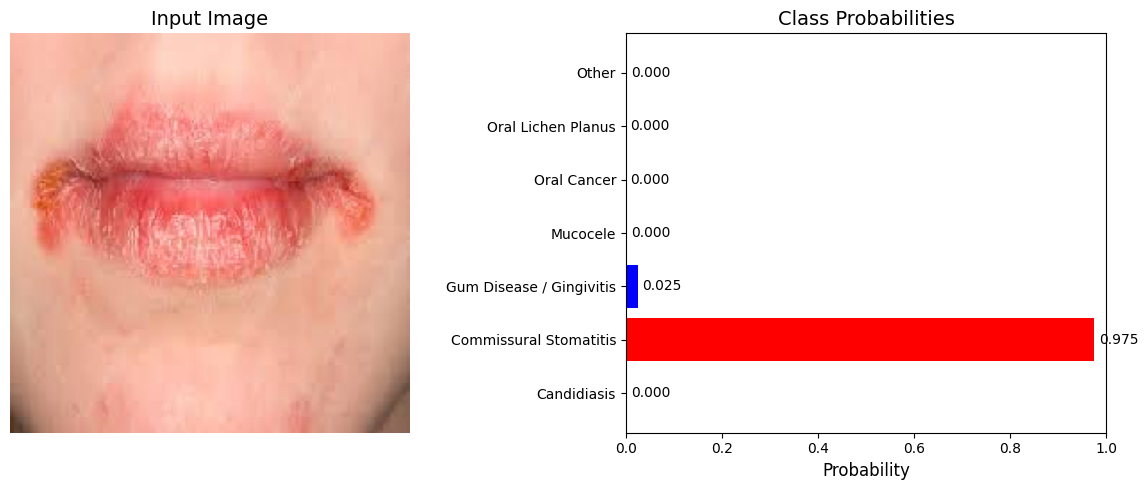


📊 Prediction Results:
   🎯 Predicted Disease: Commissural Stomatitis
   📈 Confidence: 0.9748 (97.48%)
   📁 Original Folder: CoS

🏆 Top 3 Predictions:
   1. Commissural Stomatitis: 0.9748 (97.48%)
   2. Gum Disease / Gingivitis: 0.0248 (2.48%)
   3. Other: 0.0004 (0.04%)
   ✅ High confidence prediction


('Commissural Stomatitis', np.float32(0.9748379))

In [6]:
test_image_path = "photos/Commissural Stomatitis.jpg"
test_single_image(test_image_path)

📁 Found 5 images in photos

🖼️ Processing: Commissural Stomatitis.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


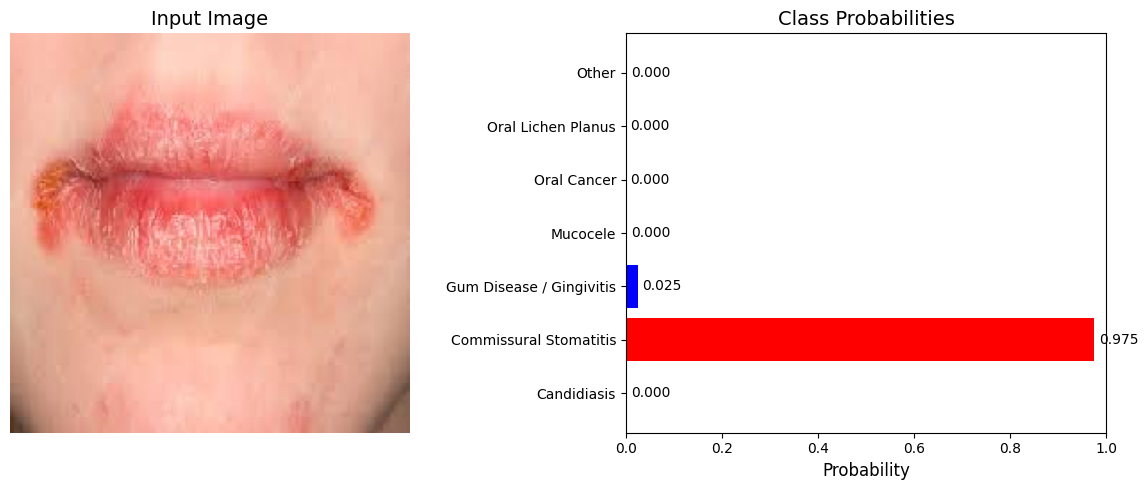


📊 Prediction Results:
   🎯 Predicted Disease: Commissural Stomatitis
   📈 Confidence: 0.9748 (97.48%)
   📁 Original Folder: CoS

🏆 Top 3 Predictions:
   1. Commissural Stomatitis: 0.9748 (97.48%)
   2. Gum Disease / Gingivitis: 0.0248 (2.48%)
   3. Other: 0.0004 (0.04%)
   ✅ High confidence prediction

🖼️ Processing: Mucocele.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


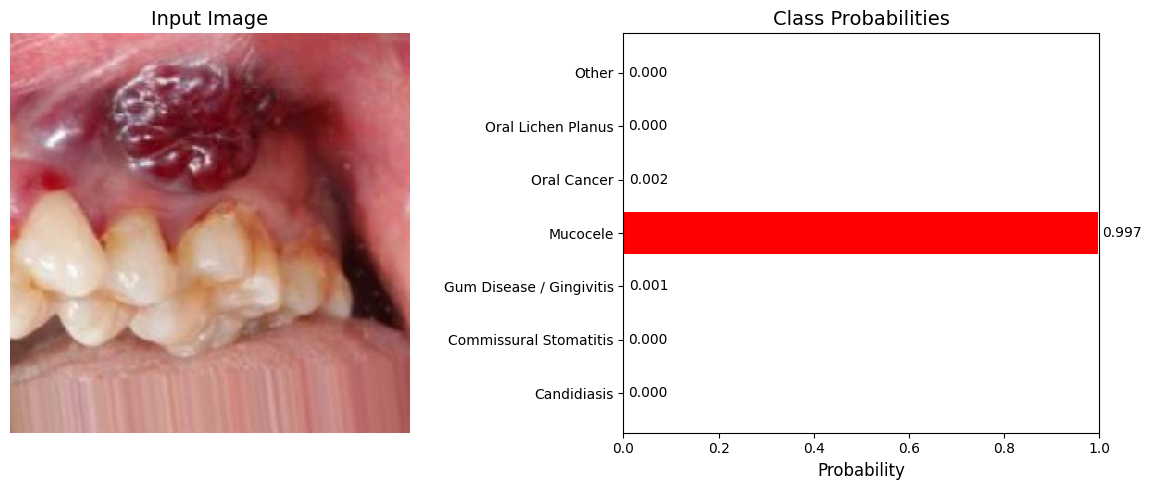


📊 Prediction Results:
   🎯 Predicted Disease: Mucocele
   📈 Confidence: 0.9966 (99.66%)
   📁 Original Folder: MC

🏆 Top 3 Predictions:
   1. Mucocele: 0.9966 (99.66%)
   2. Oral Cancer: 0.0015 (0.15%)
   3. Gum Disease / Gingivitis: 0.0012 (0.12%)
   ✅ High confidence prediction

🖼️ Processing: Oral Cancer.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


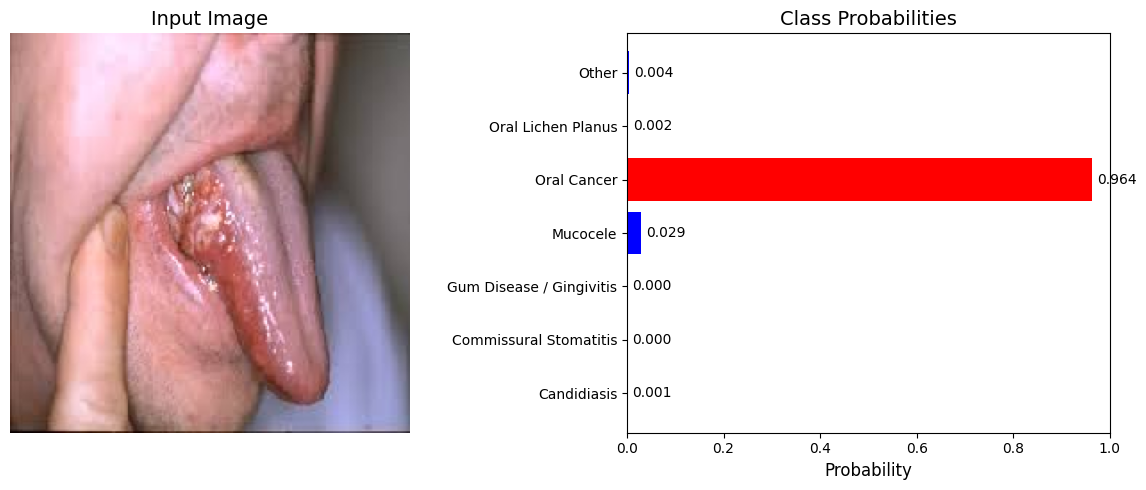


📊 Prediction Results:
   🎯 Predicted Disease: Oral Cancer
   📈 Confidence: 0.9636 (96.36%)
   📁 Original Folder: OC

🏆 Top 3 Predictions:
   1. Oral Cancer: 0.9636 (96.36%)
   2. Mucocele: 0.0295 (2.95%)
   3. Other: 0.0041 (0.41%)
   ✅ High confidence prediction

🖼️ Processing: Oral Lichen Planus.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


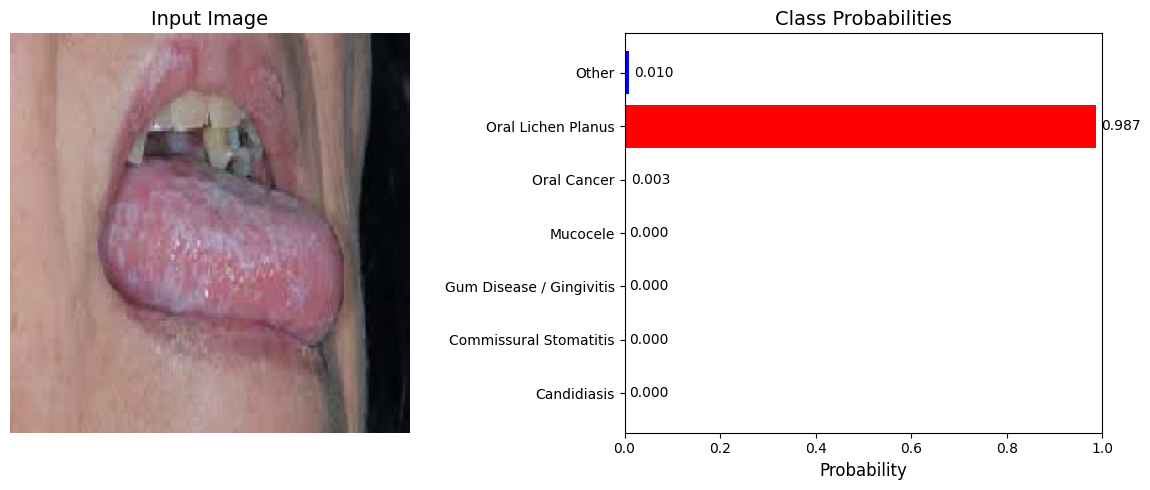


📊 Prediction Results:
   🎯 Predicted Disease: Oral Lichen Planus
   📈 Confidence: 0.9870 (98.70%)
   📁 Original Folder: OLP

🏆 Top 3 Predictions:
   1. Oral Lichen Planus: 0.9870 (98.70%)
   2. Other: 0.0095 (0.95%)
   3. Oral Cancer: 0.0033 (0.33%)
   ✅ High confidence prediction

🖼️ Processing: Planus.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


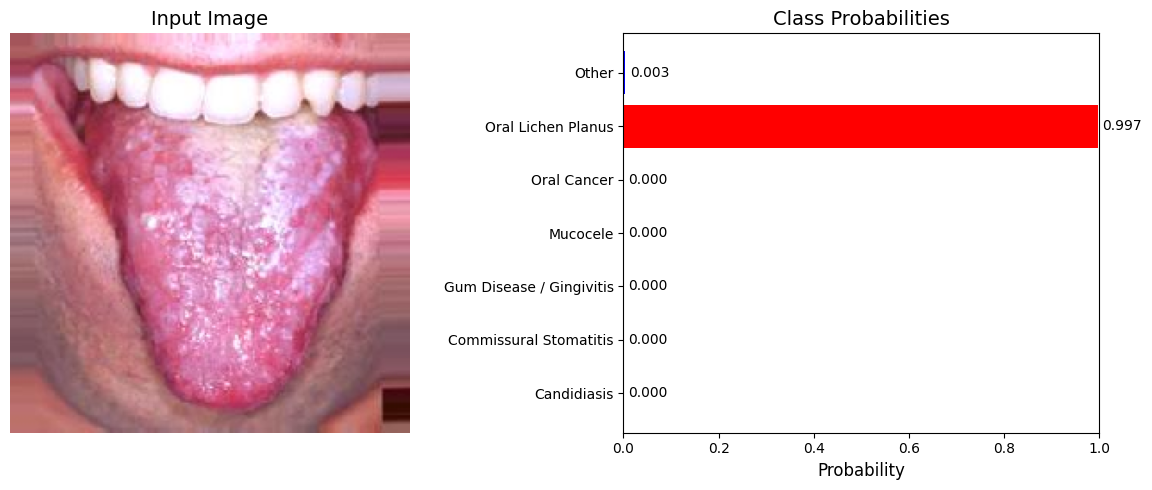


📊 Prediction Results:
   🎯 Predicted Disease: Oral Lichen Planus
   📈 Confidence: 0.9965 (99.65%)
   📁 Original Folder: OLP

🏆 Top 3 Predictions:
   1. Oral Lichen Planus: 0.9965 (99.65%)
   2. Other: 0.0033 (0.33%)
   3. Oral Cancer: 0.0001 (0.01%)
   ✅ High confidence prediction


In [7]:
test_folder_path = "photos"
results = test_multiple_images(test_folder_path)


In [8]:
def display_model_info():
    if model_info is None:
        print("❌ Model info not available")
        return
    
    print("📋 Model Information:")
    print("=" * 30)
    print(f"Input Shape: {model_info['input_shape']}")
    print(f"Number of Classes: {len(model_info['class_indices'])}")
    print("\nClass Mapping:")
    for folder, class_name in model_info['class_mapping'].items():
        print(f"  {folder} → {class_name}")
    
    print("\nClass Indices:")
    for class_name, index in model_info['class_indices'].items():
        descriptive_name = model_info['class_mapping'].get(class_name, class_name)
        print(f"  {index}: {descriptive_name}")

display_model_info()

📋 Model Information:
Input Shape: [224, 224, 3]
Number of Classes: 7

Class Mapping:
  CaS → Candidiasis
  CoS → Commissural Stomatitis
  Gum → Gum Disease / Gingivitis
  MC → Mucocele
  OC → Oral Cancer
  OLP → Oral Lichen Planus
  OT → Other

Class Indices:
  0: Candidiasis
  1: Commissural Stomatitis
  2: Gum Disease / Gingivitis
  3: Mucocele
  4: Oral Cancer
  5: Oral Lichen Planus
  6: Other



Testing: photos/Oral Cancer.jpg
🔍 Testing image: photos/Oral Cancer.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


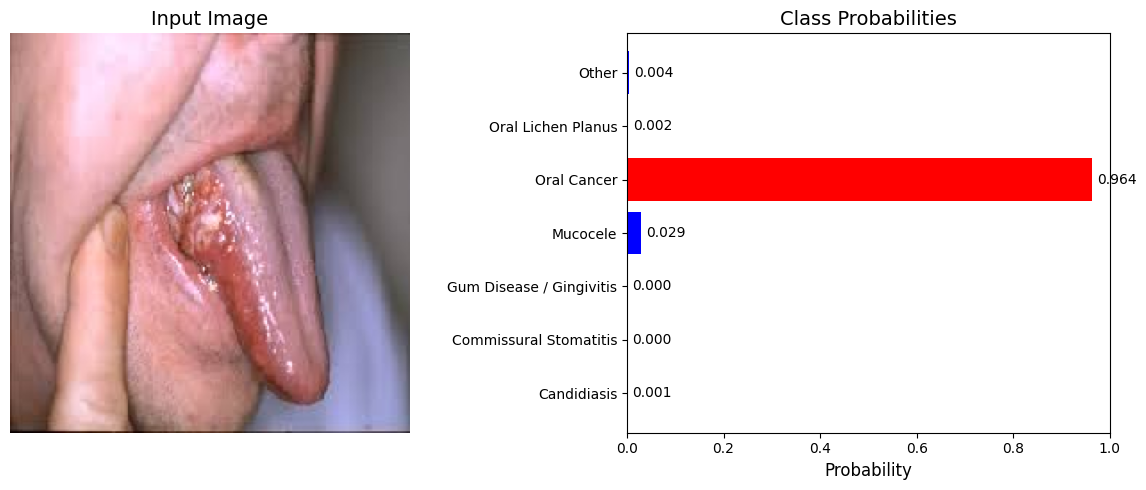


📊 Prediction Results:
   🎯 Predicted Disease: Oral Cancer
   📈 Confidence: 0.9636 (96.36%)
   📁 Original Folder: OC

🏆 Top 3 Predictions:
   1. Oral Cancer: 0.9636 (96.36%)
   2. Mucocele: 0.0295 (2.95%)
   3. Other: 0.0041 (0.41%)
   ✅ High confidence prediction

Testing: photos/Oral Lichen Planus.jpg
🔍 Testing image: photos/Oral Lichen Planus.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


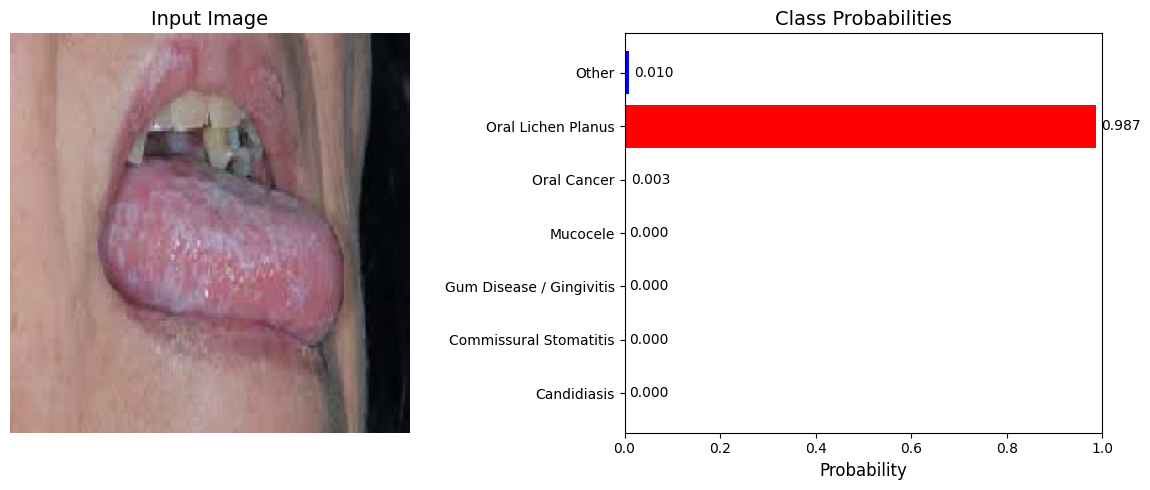


📊 Prediction Results:
   🎯 Predicted Disease: Oral Lichen Planus
   📈 Confidence: 0.9870 (98.70%)
   📁 Original Folder: OLP

🏆 Top 3 Predictions:
   1. Oral Lichen Planus: 0.9870 (98.70%)
   2. Other: 0.0095 (0.95%)
   3. Oral Cancer: 0.0033 (0.33%)
   ✅ High confidence prediction

Testing: photos/Commissural Stomatitis.jpg
🔍 Testing image: photos/Commissural Stomatitis.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


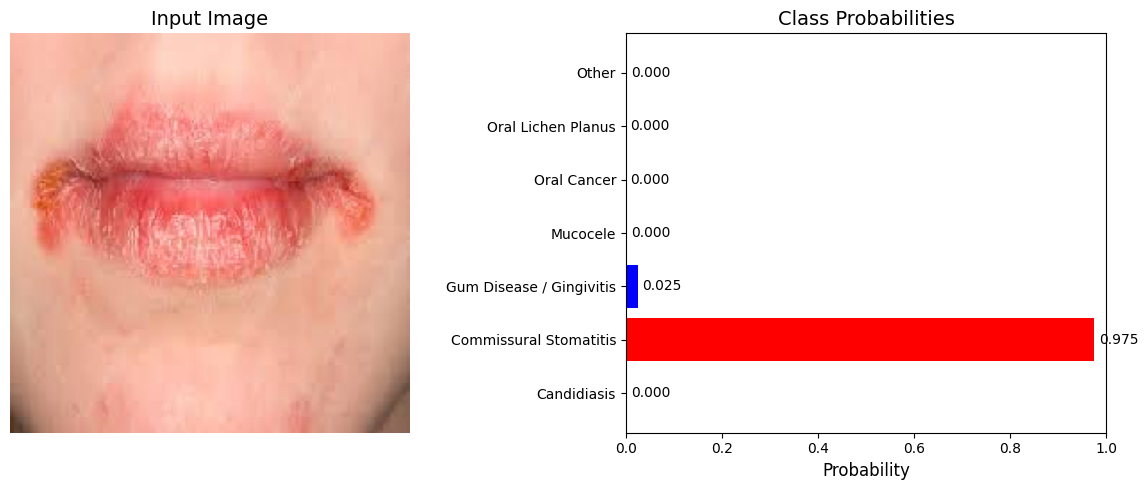


📊 Prediction Results:
   🎯 Predicted Disease: Commissural Stomatitis
   📈 Confidence: 0.9748 (97.48%)
   📁 Original Folder: CoS

🏆 Top 3 Predictions:
   1. Commissural Stomatitis: 0.9748 (97.48%)
   2. Gum Disease / Gingivitis: 0.0248 (2.48%)
   3. Other: 0.0004 (0.04%)
   ✅ High confidence prediction


In [9]:
def quick_test():
    
    sample_images = [
        "photos/Oral Cancer.jpg",
        "photos/Oral Lichen Planus.jpg", 
        "photos/Commissural Stomatitis.jpg"
    ]
    
    for img in sample_images:
        if os.path.exists(img):
            print(f"\n{'='*50}")
            print(f"Testing: {img}")
            test_single_image(img)

quick_test()